100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 246kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.80MB/s]


Epoch 1 / 20, Loss: 164.0264


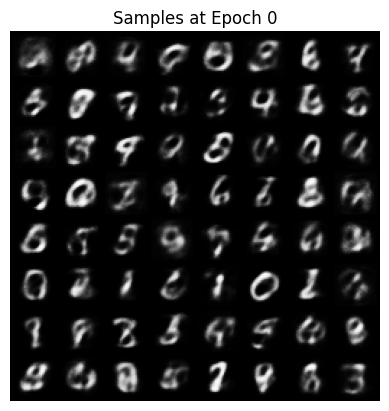

Epoch 2 / 20, Loss: 121.2315
Epoch 3 / 20, Loss: 114.5989
Epoch 4 / 20, Loss: 111.5809
Epoch 5 / 20, Loss: 109.7278
Epoch 6 / 20, Loss: 108.5184


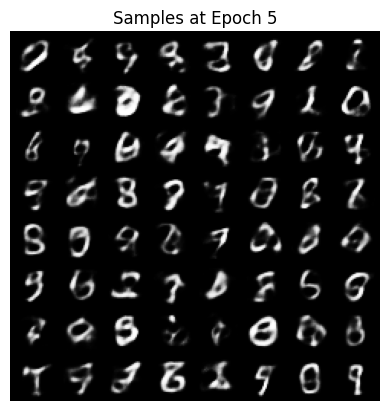

Epoch 7 / 20, Loss: 107.6193
Epoch 8 / 20, Loss: 107.0310
Epoch 9 / 20, Loss: 106.4640
Epoch 10 / 20, Loss: 106.0454
Epoch 11 / 20, Loss: 105.7011


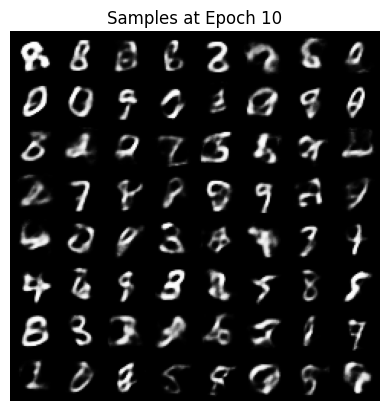

Epoch 12 / 20, Loss: 105.3887
Epoch 13 / 20, Loss: 105.1171
Epoch 14 / 20, Loss: 104.8826
Epoch 15 / 20, Loss: 104.6503
Epoch 16 / 20, Loss: 104.4671


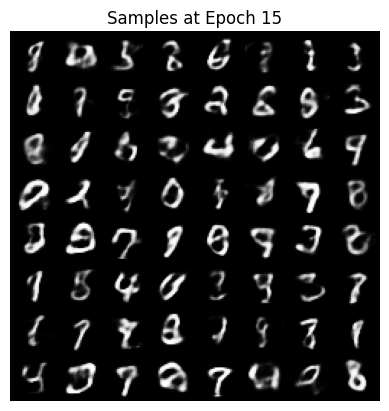

Epoch 17 / 20, Loss: 104.3264
Epoch 18 / 20, Loss: 104.1200
Epoch 19 / 20, Loss: 103.9532
Epoch 20 / 20, Loss: 103.7991


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Hyperparams
latent_dim = 20
batch_size = 128
lr = 1e-3
epochs = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps  # z = mu + std * eps

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon.view(-1, 1, 28, 28), mu, logvar

# Loss
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Setup
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

# Training Loop
for epoch in range(epochs):
    total_loss = 0
    for x, _ in dataloader:
        x = x.to(device)
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} / {epochs}, Loss: {total_loss / len(dataloader.dataset):.4f}")

    # Show generated samples every 5 epochs
    if epoch % 5 == 0:
        with torch.no_grad():
            z = torch.randn(64, latent_dim).to(device)
            samples = vae.decoder(z).view(-1, 1, 28, 28).cpu()
            grid = torchvision.utils.make_grid(samples, nrow=8)
            plt.imshow(grid.permute(1, 2, 0))
            plt.title(f"Samples at Epoch {epoch}")
            plt.axis('off')
            plt.show()
